# BloodMNIST – Federated Learning Experiments
**Variant 8**: FedMedian and Krum under data heterogeneity  
Dataset: BloodMNIST (8-class, 3-channel, multi-class classification)  
Resolutions tested: 28×28 and 64×64  
Models: Lightweight CNN baseline + ResNet18  
FL Strategies: FedMedian, Krum  
Partitioning: IID and non-IID (Dirichlet α)


## 1. Install Dependencies

In [1]:
!pip install -q "flwr[simulation]>=1.8" flwr-datasets medmnist scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports & Reproducibility

In [2]:
## Imports Libraries
import random, copy, warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import OrderedDict
from typing import Dict, List, Tuple, Optional

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from torchvision import models, transforms
from torch.utils.data import random_split, DataLoader, Subset

import medmnist
from medmnist import INFO

from flwr.common import NDArrays, Scalar, Metrics, Context, ndarrays_to_parameters, parameters_to_ndarrays
from flwr.client import NumPyClient, ClientApp
from flwr.server import ServerApp, ServerConfig, ServerAppComponents
from flwr.server.strategy import FedAvg, FedMedian, Krum
from flwr.simulation import run_simulation

## Seed: Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## check device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"MedMNIST v{medmnist.__version__}")

import warnings
warnings.filterwarnings("ignore")

Using device: cpu
MedMNIST v3.0.2


## 3. Dataset Configuration – BloodMNIST

In [3]:
data_flag = 'bloodmnist'
info = INFO[data_flag]
task = info['task']
N_CHANNELS = info['n_channels']   # 3 (RGB)
N_CLASSES = len(info['label'])   # 8 for bloodmnist
DataClass = getattr(medmnist, info['python_class'])

LABEL_NAMES = list(info['label'].values())
print(f"Task: {task}")
print(f"Channels: {N_CHANNELS}")
print(f"Classes: {N_CLASSES}")
print(f"Labels: {LABEL_NAMES}")

Task: multi-class
Channels: 3
Classes: 8
Labels: ['basophil', 'eosinophil', 'erythroblast', 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


## 4. Experiment Configuration

In [19]:
## Hyperparameters
IMAGE_SIZE=28       # 28 or 64
BATCH_SIZE=64
NUM_CLIENTS=3        # ≥ 3 Iteration 02: Vary Clients
NUM_ROUNDS=1       # FL communication rounds
LOCAL_EPOCHS=1      # Iteration 03: Vary Local Epochs
LR=0.01
MOMENTUM=0.9

# # Partitioning: 'iid' or 'noniid'
# PARTITION_MODE = 'iid'   # set to 'noniid' for heterogeneous

# Non-IID Dirichlet concentration (lower = more heterogeneous)
DIRICHLET_ALPHA = 100 # Iteration 01: Vary Dirichlet Alpha

# Counter Attack Strategy: 'fedmedian' or 'krum'
STRATEGY_NAME = 'fedmedian'

# Model: 'cnn' or 'resnet18'
MODEL_NAME = 'cnn'

print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Clients: {NUM_CLIENTS}")
print(f"Rounds: {NUM_ROUNDS}")
# print(f"Data Heterogeneity: {PARTITION_MODE}")
print(f"Dirichlet Alpha: {DIRICHLET_ALPHA}")
print(f"Strategy: {STRATEGY_NAME}")
print(f"Model: {MODEL_NAME}")

Image size: 28x28
Clients: 3
Rounds: 1
Dirichlet Alpha: 100
Strategy: fedmedian
Model: cnn


## 5. Data Loading

In [5]:
DOWNLOAD = True

def make_transform(image_size):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[.5]*3, std=[.5]*3),
    ])

transform = make_transform(IMAGE_SIZE)

train_dataset_full = DataClass(split='train', transform=transform, download=DOWNLOAD, size=IMAGE_SIZE)
val_dataset = DataClass(split='val', transform=transform, download=DOWNLOAD, size=IMAGE_SIZE)
test_dataset = DataClass(split='test', transform=transform, download=DOWNLOAD, size=IMAGE_SIZE)

# data loaders
train_loader_full = DataLoader(train_dataset_full, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_dataset_full)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 11959 | Val: 1712 | Test: 3421


### Montage
View Samples of Images from training set

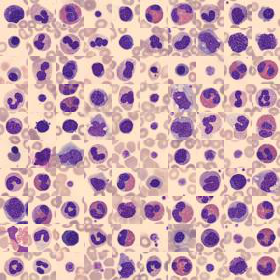

In [6]:
train_dataset_full.montage(length=10)

## 6. Data Partitioning

In [7]:
# def iid_partition(dataset, num_clients, seed=SEED):
#     """Uniformly random IID partition."""
#     n = len(dataset)
#     indices = list(range(n))
#     np.random.seed(seed)
#     np.random.shuffle(indices)
#     size = n // num_clients
#     parts = []
#     for i in range(num_clients):
#         start = i * size
#         end   = start + size if i < num_clients - 1 else n
#         parts.append(Subset(dataset, indices[start:end]))
#     return parts


# def dirichlet_partition(dataset, num_clients, alpha, seed=SEED):
#     """Non-IID Dirichlet partition – skews class distribution per client."""
#     # Extract integer labels
#     labels = []
#     for _, lbl in dataset:
#         if isinstance(lbl, (np.ndarray, torch.Tensor)):
#             lbl = int(np.array(lbl).squeeze())
#         labels.append(int(lbl))
#     labels = np.array(labels)
#     n_classes = len(np.unique(labels))

#     np.random.seed(seed)
#     class_indices = {c: np.where(labels == c)[0].tolist() for c in range(n_classes)}
#     # Shuffle within each class
#     for c in class_indices:
#         np.random.shuffle(class_indices[c])

#     client_indices = [[] for _ in range(num_clients)]
#     for c in range(n_classes):
#         idx = class_indices[c]
#         proportions = np.random.dirichlet([alpha] * num_clients)
#         proportions = (np.cumsum(proportions) * len(idx)).astype(int)[:-1]
#         splits = np.split(idx, proportions)
#         for cid, split in enumerate(splits):
#             client_indices[cid].extend(split.tolist())

#     return [Subset(dataset, idxs) for idxs in client_indices]


# def make_partitions(dataset, mode, num_clients, alpha=DIRICHLET_ALPHA):
#     if mode == 'iid':
#         return iid_partition(dataset, num_clients)
#     else:
#         return dirichlet_partition(dataset, num_clients, alpha)


# partitions = make_partitions(train_dataset_full, PARTITION_MODE, NUM_CLIENTS)
# for i, p in enumerate(partitions):
#     print(f"Client {i}: {len(p)} samples")


In [8]:
def dirichlet_partition(dataset, num_clients, alpha, seed=SEED):
    """Non-IID Dirichlet partition - skews class distribution per client."""
    # Extract integer labels
    labels = []
    for _, lbl in dataset:
        if isinstance(lbl, (np.ndarray, torch.Tensor)):
            lbl = int(np.array(lbl).squeeze())
        labels.append(int(lbl))
    labels = np.array(labels)
    n_classes = len(np.unique(labels))

    np.random.seed(seed)
    class_indices = {c: np.where(labels == c)[0].tolist() for c in range(n_classes)}
    # Shuffle within each class
    for c in class_indices:
        np.random.shuffle(class_indices[c])

    client_indices = [[] for _ in range(num_clients)]
    for c in range(n_classes):
        idx = class_indices[c]
        proportions = np.random.dirichlet([alpha] * num_clients)
        proportions = (np.cumsum(proportions) * len(idx)).astype(int)[:-1]
        splits = np.split(idx, proportions)
        for cid, split in enumerate(splits):
            client_indices[cid].extend(split.tolist())

    return [Subset(dataset, idxs) for idxs in client_indices]

partitions = dirichlet_partition(train_dataset_full, NUM_CLIENTS, DIRICHLET_ALPHA)
for i, p in enumerate(partitions):
    print(f"Client {i}: {len(p)} samples")

Client 0: 4145 samples
Client 1: 3897 samples
Client 2: 3917 samples


### Partition Label Distribution

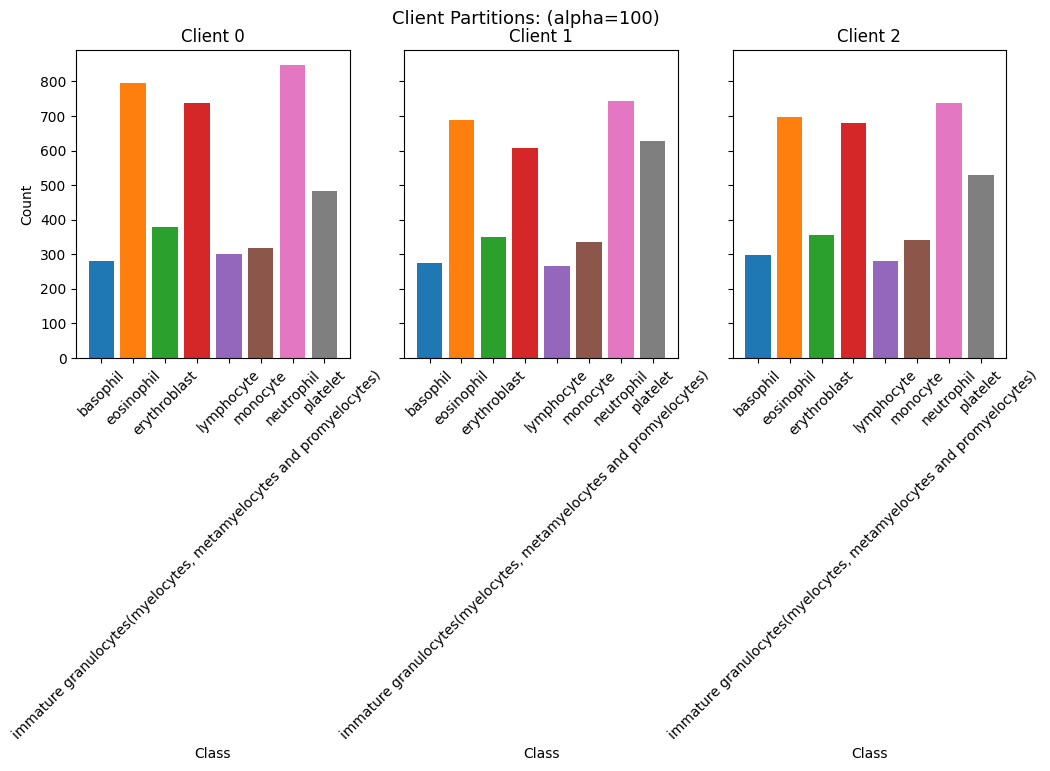

In [9]:
def extract_labels(subset):
    labels = []
    for _, lbl in subset:
        if isinstance(lbl, (np.ndarray, torch.Tensor)):
            lbl = int(np.array(lbl).squeeze())
        labels.append(int(lbl))
    return labels

fig, axes = plt.subplots(1, NUM_CLIENTS, figsize=(4*NUM_CLIENTS, 4), sharey=True)
for cid, part in enumerate(partitions):
    lbls = extract_labels(part)
    ax = axes[cid] if NUM_CLIENTS > 1 else axes
    counts = [lbls.count(c) for c in range(N_CLASSES)]
    ax.bar(LABEL_NAMES, counts, color=sns.color_palette("tab10", N_CLASSES))
    ax.set_title(f"Client {cid}")
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel("Class")
    if cid == 0:
        ax.set_ylabel("Count")

fig.suptitle(f"Client Partitions: (alpha={DIRICHLET_ALPHA})", fontsize=13)
plt.tight_layout()
plt.savefig(f"client_partitions_alpha_{DIRICHLET_ALPHA}_{IMAGE_SIZE}.png", dpi=120, bbox_inches='tight')
plt.show()


## 7. Model Architectures

In [ ]:
class LightCNN(nn.Module):
    """Lightweight CNN baseline for BloodMNIST."""
    def __init__(self, n_channels=3, n_classes=8):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(n_channels, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def create_resnet18(n_channels=3, n_classes=8, image_size=28):
    model = models.resnet18(weights=None)
    # Adapt first conv for smaller images
    if image_size <= 32:
        model.conv1 = nn.Conv2d(n_channels, 64, kernel_size=3,
                                 stride=1, padding=1, bias=False)
        model.maxpool = nn.Identity()
    else:
        model.conv1 = nn.Conv2d(n_channels, 64, kernel_size=7,
                                 stride=2, padding=3, bias=False)
    model.fc = nn.Linear(model.fc.in_features, n_classes)
    return model


def create_model(name=MODEL_NAME, image_size=IMAGE_SIZE):
    if name == 'cnn':
        return LightCNN(N_CHANNELS, N_CLASSES)
    else:
        return create_resnet18(N_CHANNELS, N_CLASSES, image_size)

# model parameters
m = create_model()
params = sum(p.numel() for p in m.parameters())
print(f"Model: {MODEL_NAME} | Parameters: {params:,}")


Model: cnn | Parameters: 620,296


## 8. Training & Evaluation Functions

In [11]:
from sklearn.metrics import f1_score

criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.squeeze().long().to(device)
        optimizer.zero_grad()
        out  = model(images)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)

def evaluate(model, loader, device=DEVICE):
    model.eval()
    model.to(device)
    total_loss, y_true, y_pred = 0.0, [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)
            out  = model(images)
            loss = criterion(out, labels)
            total_loss += loss.item() * images.size(0)
            preds = torch.argmax(out, dim=1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    acc  = (np.array(y_pred) == np.array(y_true)).mean()
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return avg_loss, acc, f1

# Centralised baseline
def run_centralised(epochs=5, lr=LR, model_name=MODEL_NAME):
    model = create_model(model_name).to(DEVICE)
    opt   = optim.SGD(model.parameters(), lr=lr, momentum=MOMENTUM)
    history = []
    for epoch in range(1, epochs + 1):
        tr_loss = train_one_epoch(model, train_loader_full, opt, DEVICE)
        val_loss, val_acc, val_f1 = evaluate(model, val_loader)
        history.append(dict(epoch=epoch, train_loss=tr_loss,
                            val_loss=val_loss, val_acc=val_acc, val_f1=val_f1))
        print(f"Epoch {epoch}/{epochs} | train_loss={tr_loss:.4f} "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_f1={val_f1:.4f}")
    test_loss, test_acc, test_f1 = evaluate(model, test_loader)
    print(f"\nTest | loss={test_loss:.4f} acc={test_acc:.4f} f1={test_f1:.4f}")
    return model, history

### 8a. Centralised Baseline (model sanity check)

In [12]:
central_model, central_history = run_centralised(epochs=2)

Epoch 1/2 | train_loss=0.7440 val_loss=0.4131 val_acc=0.8446 val_f1=0.8189
Epoch 2/2 | train_loss=0.3913 val_loss=0.3552 val_acc=0.8732 val_f1=0.8541

Test | loss=0.3585 acc=0.8761 f1=0.8574


## 9. Flower FL Components

In [21]:
### Parameter helpers ###
def get_params(model):
    return [v.cpu().numpy() for _, v in model.state_dict().items()]

def set_params(model, parameters):
    keys = list(model.state_dict().keys())
    state = OrderedDict({k: torch.tensor(v) for k, v in zip(keys, parameters)})
    model.load_state_dict(state, strict=True)

In [13]:
################## CLIENT ##################
class FlowerClient(NumPyClient):
    def __init__(self, trainloader, valloader, model_name=MODEL_NAME, local_epochs=LOCAL_EPOCHS, lr=LR):
        self.trainloader = trainloader
        self.valloader = valloader
        self.model = create_model(model_name).to(DEVICE)
        self.local_epochs = local_epochs
        self.lr = lr

    def fit(self, parameters, config):
        set_params(self.model, parameters)
        opt = optim.SGD(self.model.parameters(), lr=self.lr, momentum=MOMENTUM)
        for _ in range(self.local_epochs):
            train_one_epoch(self.model, self.trainloader, opt, DEVICE)
        return get_params(self.model), len(self.trainloader.dataset), {}

    def evaluate(self, parameters, config):
        set_params(self.model, parameters)
        loss, acc, f1 = evaluate(self.model, self.valloader)
        return float(loss), len(self.valloader.dataset), {"accuracy": acc, "f1": f1}

In [ ]:
######### CLIENT FUNCTION #########
def make_client_fn(partitions, model_name=MODEL_NAME):
    def client_fn(context: Context):
        pid  = int(context.node_config["partition-id"])
        part = partitions[pid]
        val_sz  = max(1, int(len(part) * 0.1))
        train_sz = len(part) - val_sz
        tr, va = random_split(part, [train_sz, val_sz], generator=torch.Generator().manual_seed(SEED))
        tr_loader = DataLoader(tr, BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
        va_loader = DataLoader(va, BATCH_SIZE*2, shuffle=False, num_workers=2, pin_memory=True)
        return FlowerClient(tr_loader, va_loader, model_name).to_client()
    return client_fn

In [15]:
#### AGGREGATE METRICS #####
def weighted_average(metrics: List[Tuple[int, Metrics]]) -> Metrics:
    total = sum(n for n, _ in metrics)
    acc = sum(n * m["accuracy"] for n, m in metrics) / total
    f1 = sum(n * m["f1"] for n, m in metrics) / total
    return {"accuracy": acc, "f1": f1}

In [16]:
############## LOGGING ##############
class LoggingStrategy:
    """Records per-round metrics."""

    def __init__(self, strategy):
        self._strategy = strategy
        self.history = []

    def __getattr__(self, name):
        # Delegate unknown attribute lookups to the inner strategy
        return getattr(self._strategy, name)
    
    def aggregate_evaluate(self, server_round, results, failures):
        aggregated = self._strategy.aggregate_evaluate(server_round, results, failures)
        if aggregated is not None:
            loss, metrics = aggregated
            self.history.append({
                "round": server_round,
                "val_loss": loss,
                "accuracy": metrics.get("accuracy", float("nan")),
                "f1": metrics.get("f1", float("nan")),
            })
        return aggregated

    def configure_fit(self, server_round, parameters, client_manager):
        return self._strategy.configure_fit(server_round, parameters, client_manager)

    def configure_evaluate(self, server_round, parameters, client_manager):
        return self._strategy.configure_evaluate(server_round, parameters, client_manager)

    def aggregate_fit(self, server_round, results, failures):
        return self._strategy.aggregate_fit(server_round, results, failures)

    def evaluate(self, server_round, parameters):
        return self._strategy.evaluate(server_round, parameters)

    def initialize_parameters(self, client_manager):
        return self._strategy.initialize_parameters(client_manager)

## 10. Run FL Experiment

In [17]:
def build_strategy(name, model, num_clients):
    """Return the chosen Flower strategy."""
    ndarrays = get_params(model)
    init_params = ndarrays_to_parameters(ndarrays)

    common = dict(
        fraction_fit = 1.0,
        fraction_evaluate = 1.0,
        min_fit_clients = num_clients,
        min_evaluate_clients = num_clients,
        min_available_clients = num_clients,
        evaluate_metrics_aggregation_fn = weighted_average,
        initial_parameters = init_params,
    )

    if name == 'fedmedian':
        return FedMedian(**common)
    elif name == 'krum':
        # num_malicious=0 for fair comparison; set to >0 for robustness tests
        return Krum(num_clients=num_clients, num_malicious=0,
                    num_fit_clients=num_clients,
                    num_eval_clients=num_clients,
                    min_available_clients=num_clients,
                    evaluate_metrics_aggregation_fn=weighted_average,
                    initial_parameters=init_params)
    else:
        raise ValueError(f"Unknown strategy: {name}")


In [18]:
def run_fl_experiment(
        strategy_name = STRATEGY_NAME,
        model_name = MODEL_NAME,
        image_size = IMAGE_SIZE,
        num_clients = NUM_CLIENTS,
        num_rounds = NUM_ROUNDS,
        alpha = DIRICHLET_ALPHA,
):
    """Full FL experiment returning the round history."""

    print(f"\n{'='*60}")
    print(f"Experiment: strategy={strategy_name} | model={model_name} | "
          f"size={image_size} | alpha={alpha}")
    print(f"{'='*60}\n")

    # 1. Partitions (re-built with correct image_size transform)
    tf = make_transform(image_size)
    ds_train = DataClass(split='train', transform=tf, download=True, size=image_size)
    # parts = make_partitions(ds_train, partition_mode, num_clients, alpha)
    parts = dirichlet_partition(ds_train, num_clients, alpha)

    # 2. Strategy (with logging wrapper)
    global_model = create_model(model_name, image_size)
    base_strategy = build_strategy(strategy_name, global_model, num_clients)
    logged_strategy = LoggingStrategy(base_strategy)

    # 3. server_fn
    def server_fn(context: Context):
        return ServerAppComponents(
            strategy = logged_strategy,
            config = ServerConfig(num_rounds=num_rounds),
        )

    # 4. client_fn
    fn = make_client_fn(parts, model_name)

    server_app = ServerApp(server_fn=server_fn)
    client_app = ClientApp(client_fn=fn)

    run_simulation(
        server_app = server_app,
        client_app = client_app,
        num_supernodes = num_clients,
        backend_config = {"client_resources": {"num_cpus": 1, "num_gpus": 0.0}},
    )

    return logged_strategy.history

### 10a. Single Experiment (configured above)

In [22]:
history = run_fl_experiment()

# Print summary
print("\nRound | Val Loss | Accuracy | F1")
print("-" * 40)
for r in history:
    print(f"  {r['round']:2d}  |  {r['val_loss']:.4f}  |  {r['accuracy']:.4f}  | {r['f1']:.4f}")


Experiment: strategy=fedmedian | model=cnn | size=28 | alpha=100




            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower ServerApp, config: num_rounds=10, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters
INFO :      Evaluation returned no results (`None`)
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)
(raylet) Stack (most recent call first):
(raylet)   File "c:\Users\shast\Documents\Data_warehouse\python\pyenv\Lib\site-packages\ray\_private\worker.py", line 628 in Windows fatal exception: job_logging_config
(raylet)   File "c:\Users\shast\Documents\Data_warehouse\python\pyenv\Lib\site-packages\ray\_private\worker.py", line 2801 in disconnect
(raylet)   File "c:\Users\shast\Documents\Data_warehouse\python\pyenv\Lib\site-packages\ray\_private\worker.py", line 2132 in access violation


Round | Val Loss | Accuracy | F1
----------------------------------------
   1  |  2.0837  |  0.3936  | 0.3136
   2  |  0.5185  |  0.8317  | 0.7924
   3  |  0.6604  |  0.7362  | 0.6897
   4  |  0.4253  |  0.8585  | 0.8234
   5  |  0.3195  |  0.8878  | 0.8543
   6  |  0.3161  |  0.8878  | 0.8575
   7  |  0.3475  |  0.8760  | 0.8449
   8  |  0.3477  |  0.8702  | 0.8393
   9  |  0.3908  |  0.8752  | 0.8470
  10  |  0.3268  |  0.8811  | 0.8540


## 11. Plotting Utilities

In [23]:
def plot_history(histories: dict, title: str, filename: str):
    """Plot val_loss, accuracy and F1 from multiple run histories.

    histories: {label: list_of_round_dicts}
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    metrics = [("val_loss", "Validation Loss"),
               ("accuracy", "Accuracy"),
               ("f1",       "Macro F1")]

    for ax, (key, ylabel) in zip(axes, metrics):
        for label, hist in histories.items():
            rounds = [r["round"] for r in hist]
            vals   = [r[key]    for r in hist]
            ax.plot(rounds, vals, marker='o', label=label)
        ax.set_xlabel("Round")
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.5)

    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")

## 12. Experiment Set 1 – FedMedian vs Krum (IID, CNN, 28×28)
Both strategies tested under identical IID conditions to establish a fair baseline comparison.


In [ ]:
exp1_fedmedian = run_fl_experiment(
    partition_mode='iid', strategy_name='fedmedian',
    model_name='cnn', image_size=28)

exp1_krum = run_fl_experiment(
    partition_mode='iid', strategy_name='krum',
    model_name='cnn', image_size=28)

plot_history(
    {"FedMedian": exp1_fedmedian, "Krum": exp1_krum},
    title    = "Strategy Comparison – IID | CNN | 28×28",
    filename = "exp1_strategy_iid_cnn_28.png",
)

## 13. Experiment Set 2 – IID vs Non-IID (FedMedian, CNN, 28×28)
Non-IID uses Dirichlet α=0.5, which creates realistic per-client class imbalance.


In [ ]:
exp2_iid = run_fl_experiment(
    partition_mode='iid', strategy_name='fedmedian',
    model_name='cnn', image_size=28)

exp2_noniid = run_fl_experiment(
    partition_mode='noniid', strategy_name='fedmedian',
    model_name='cnn', image_size=28, alpha=0.5)

plot_history(
    {"IID": exp2_iid, "Non-IID α=0.5": exp2_noniid},
    title    = "IID vs Non-IID – FedMedian | CNN | 28×28",
    filename = "exp2_partition_fedmedian_cnn_28.png",
)


## 14. Experiment Set 3 – CNN vs ResNet18 (FedMedian, IID, 28×28)
Compare the lightweight baseline model against ResNet18 under the same FL setup.


In [ ]:
exp3_cnn = run_fl_experiment(
    partition_mode='iid', strategy_name='fedmedian',
    model_name='cnn', image_size=28)

exp3_resnet = run_fl_experiment(
    partition_mode='iid', strategy_name='fedmedian',
    model_name='resnet18', image_size=28)

plot_history(
    {"CNN": exp3_cnn, "ResNet18": exp3_resnet},
    title    = "Model Comparison – FedMedian | IID | 28×28",
    filename = "exp3_model_fedmedian_iid_28.png",
)


## 15. Experiment Set 4 – Resolution 28×28 vs 64×64 (FedMedian, CNN, Non-IID)
Higher resolution may improve accuracy but increases communication & compute cost.


In [ ]:
exp4_28 = run_fl_experiment(
    partition_mode='noniid', strategy_name='fedmedian',
    model_name='cnn', image_size=28, alpha=0.5)

exp4_64 = run_fl_experiment(
    partition_mode='noniid', strategy_name='fedmedian',
    model_name='cnn', image_size=64, alpha=0.5)

plot_history(
    {"28×28": exp4_28, "64×64": exp4_64},
    title    = "Resolution Comparison – FedMedian | CNN | Non-IID α=0.5",
    filename = "exp4_resolution_fedmedian_cnn_noniid.png",
)


## 16. Experiment Set 5 – Effect of Dirichlet α (FedMedian, CNN, 28×28)
Vary α to show how data heterogeneity level impacts convergence. Lower α = more heterogeneous.


In [ ]:
alpha_histories = {}
for alpha_val in [0.1, 0.5, 1.0, 5.0]:
    alpha_histories[f"α={alpha_val}"] = run_fl_experiment(
        partition_mode='noniid', strategy_name='fedmedian',
        model_name='cnn', image_size=28, alpha=alpha_val)

plot_history(
    alpha_histories,
    title    = "Dirichlet α Sweep – FedMedian | CNN | 28×28",
    filename = "exp5_alpha_sweep_fedmedian_cnn_28.png",
)


## 17. Experiment Set 6 – Robustness: Krum with Simulated Malicious Clients
Krum is designed to be Byzantine-robust. Here we compare it against FedMedian under non-IID.


In [ ]:
exp6_fedmedian_noniid = run_fl_experiment(
    partition_mode='noniid', strategy_name='fedmedian',
    model_name='cnn', image_size=28, alpha=0.5)

exp6_krum_noniid = run_fl_experiment(
    partition_mode='noniid', strategy_name='krum',
    model_name='cnn', image_size=28, alpha=0.5)

plot_history(
    {"FedMedian Non-IID": exp6_fedmedian_noniid,
     "Krum Non-IID":      exp6_krum_noniid},
    title    = "Robustness: FedMedian vs Krum | Non-IID α=0.5 | CNN | 28×28",
    filename = "exp6_robustness_noniid.png",
)


## 18. Final Test-Set Evaluation

In [ ]:
# Train a final model with best config found from experiments
# (Adjust model_name and strategy_name based on your findings)

print("Training final model for test evaluation...")
final_model = create_model('cnn', IMAGE_SIZE).to(DEVICE)
opt = optim.SGD(final_model.parameters(), lr=LR, momentum=MOMENTUM)

N_FINAL_EPOCHS = 10
for epoch in range(1, N_FINAL_EPOCHS + 1):
    # Use all training data from all partitions combined
    tr_loss = train_one_epoch(final_model, train_loader_full, opt, DEVICE)
    val_loss, val_acc, val_f1 = evaluate(final_model, val_loader)
    print(f"Epoch {epoch:2d}/{N_FINAL_EPOCHS} | train={tr_loss:.4f} "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_f1={val_f1:.4f}")

test_loss, test_acc, test_f1 = evaluate(final_model, test_loader)
print(f"\n{'='*50}")
print(f"FINAL TEST RESULTS")
print(f"  Loss     : {test_loss:.4f}")
print(f"  Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  Macro F1 : {test_f1:.4f}")
print(f"{'='*50}")


## 19. Results Summary Table

In [ ]:
def last_metrics(hist):
    """Return final round metrics from a history list."""
    if not hist:
        return {"accuracy": float("nan"), "f1": float("nan"), "val_loss": float("nan")}
    return hist[-1]

results = {
    "FedMedian IID CNN 28":         last_metrics(exp1_fedmedian),
    "Krum IID CNN 28":              last_metrics(exp1_krum),
    "FedMedian non-IID CNN 28":     last_metrics(exp2_noniid),
    "FedMedian IID ResNet18 28":    last_metrics(exp3_resnet),
    "FedMedian non-IID CNN 64":     last_metrics(exp4_64),
}

df = pd.DataFrame([
    {"Experiment": name,
     "Val Loss":   v["val_loss"],
     "Accuracy":   v["accuracy"],
     "Macro F1":   v["f1"]}
    for name, v in results.items()
])
df = df.sort_values("Accuracy", ascending=False).reset_index(drop=True)
print(df.to_string(index=False, float_format="{:.4f}".format))
